In [29]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("ggtree")
})

In [30]:
tree <- ape::read.tree("../../R/thirdparty/Phylogenetic Comparative Methods in R/8/elopomorph.tre") # just 61 species
data <- read.csv("../../R/thirdparty/Phylogenetic Comparative Methods in R/8/elopomorph.csv")
colnames(data) <- c("species", "feedmode", "maxtl")

stopifnot(all(data$species %in% tree$tip.label))
data <- data[match(tree$tip.label, data$species), ] # name match the dataset
stopifnot(all(data$species == tree$tip.label))

In [31]:
options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 250) 

In [32]:
data$feedmode |> table()


   bite suction 
     31      30 

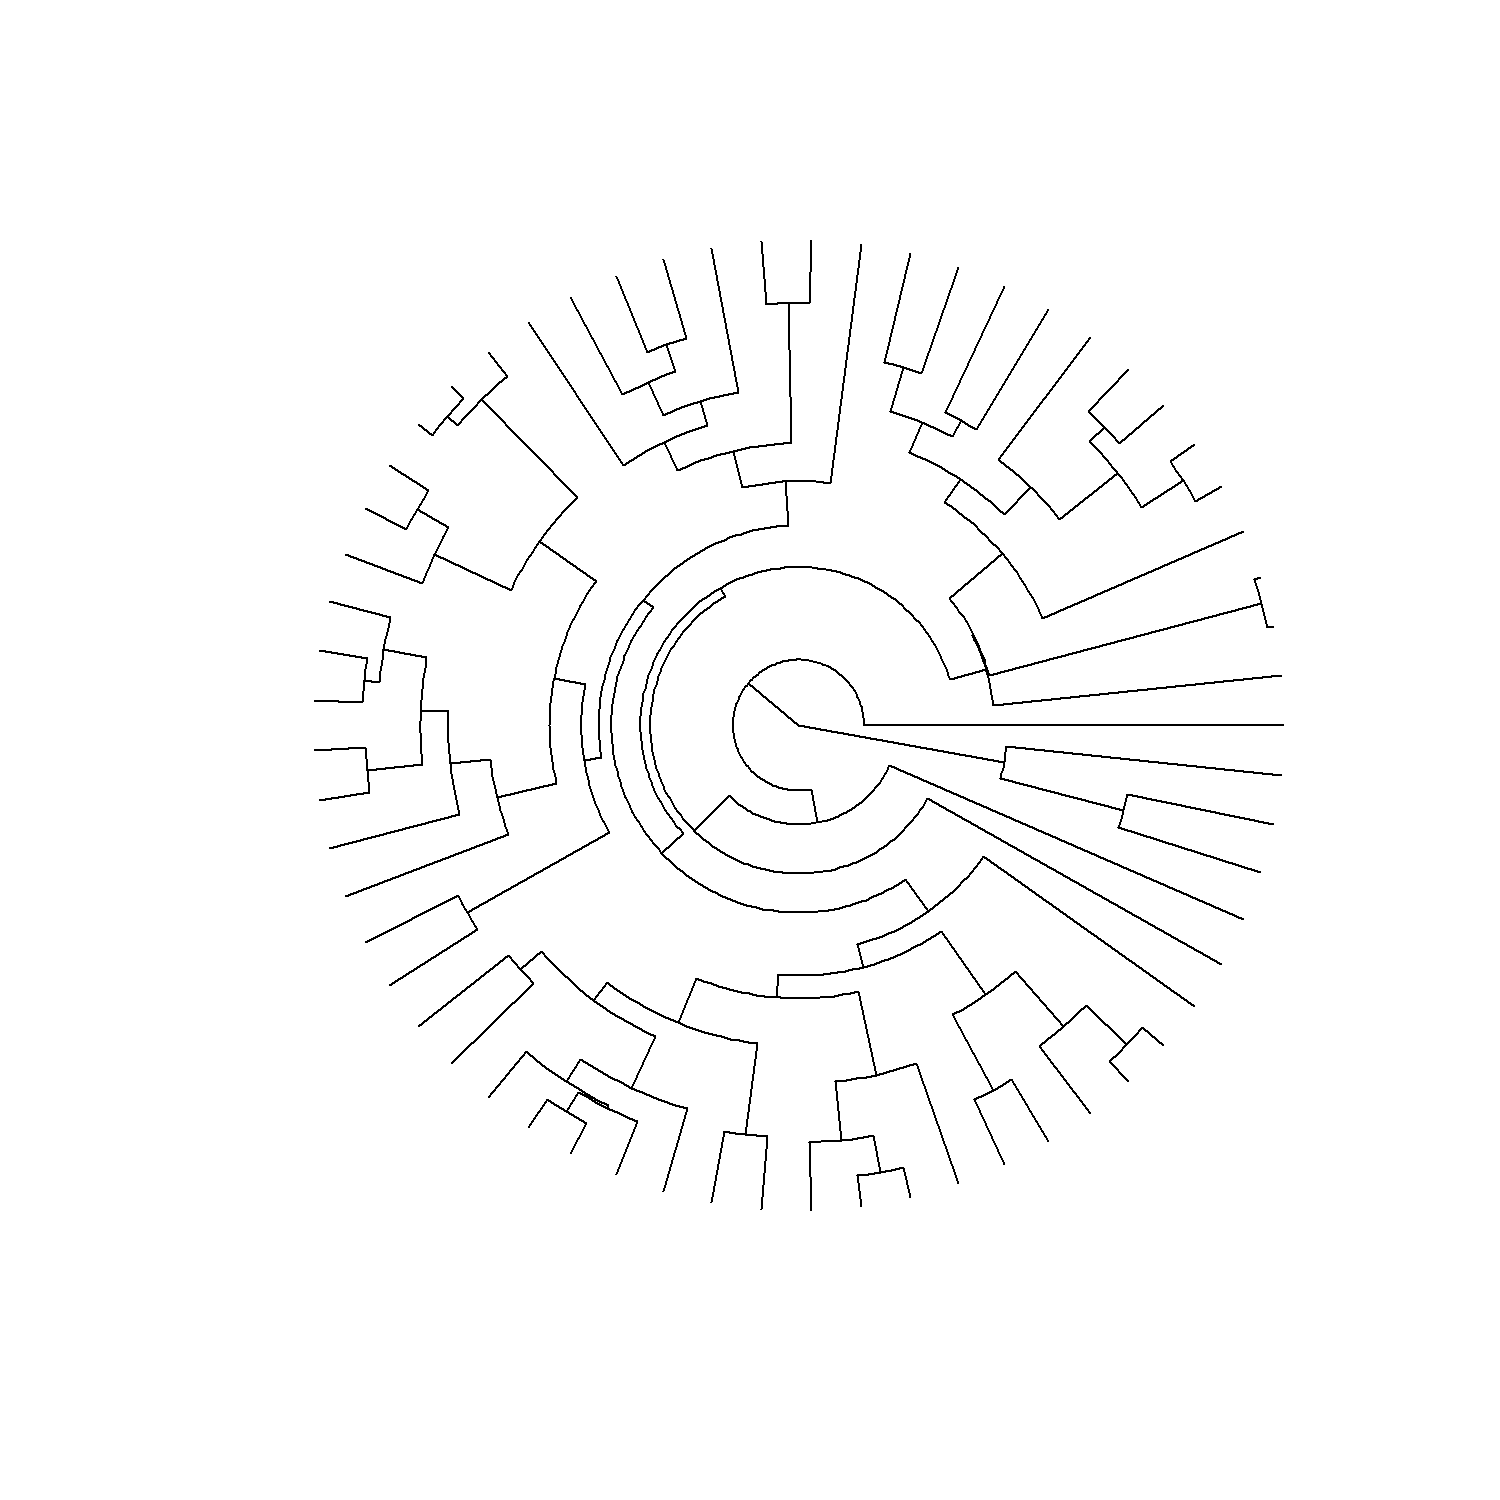

In [33]:
plot(tree, type = "fan", show.tip.label = FALSE)
ape::tiplabels(tip = data[data$feedmode == "bite", "species"], col = "red", pch=21, cex = 3)
ape::tiplabels(tip = data[data$feedmode == "suction", "species"], col = "blue", pch=21, cex = 3, adj = 1)

In [39]:
seq_along(tree$tip.label)

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50
[51] 51 52 53 54 55 56 57 58 59 60 61

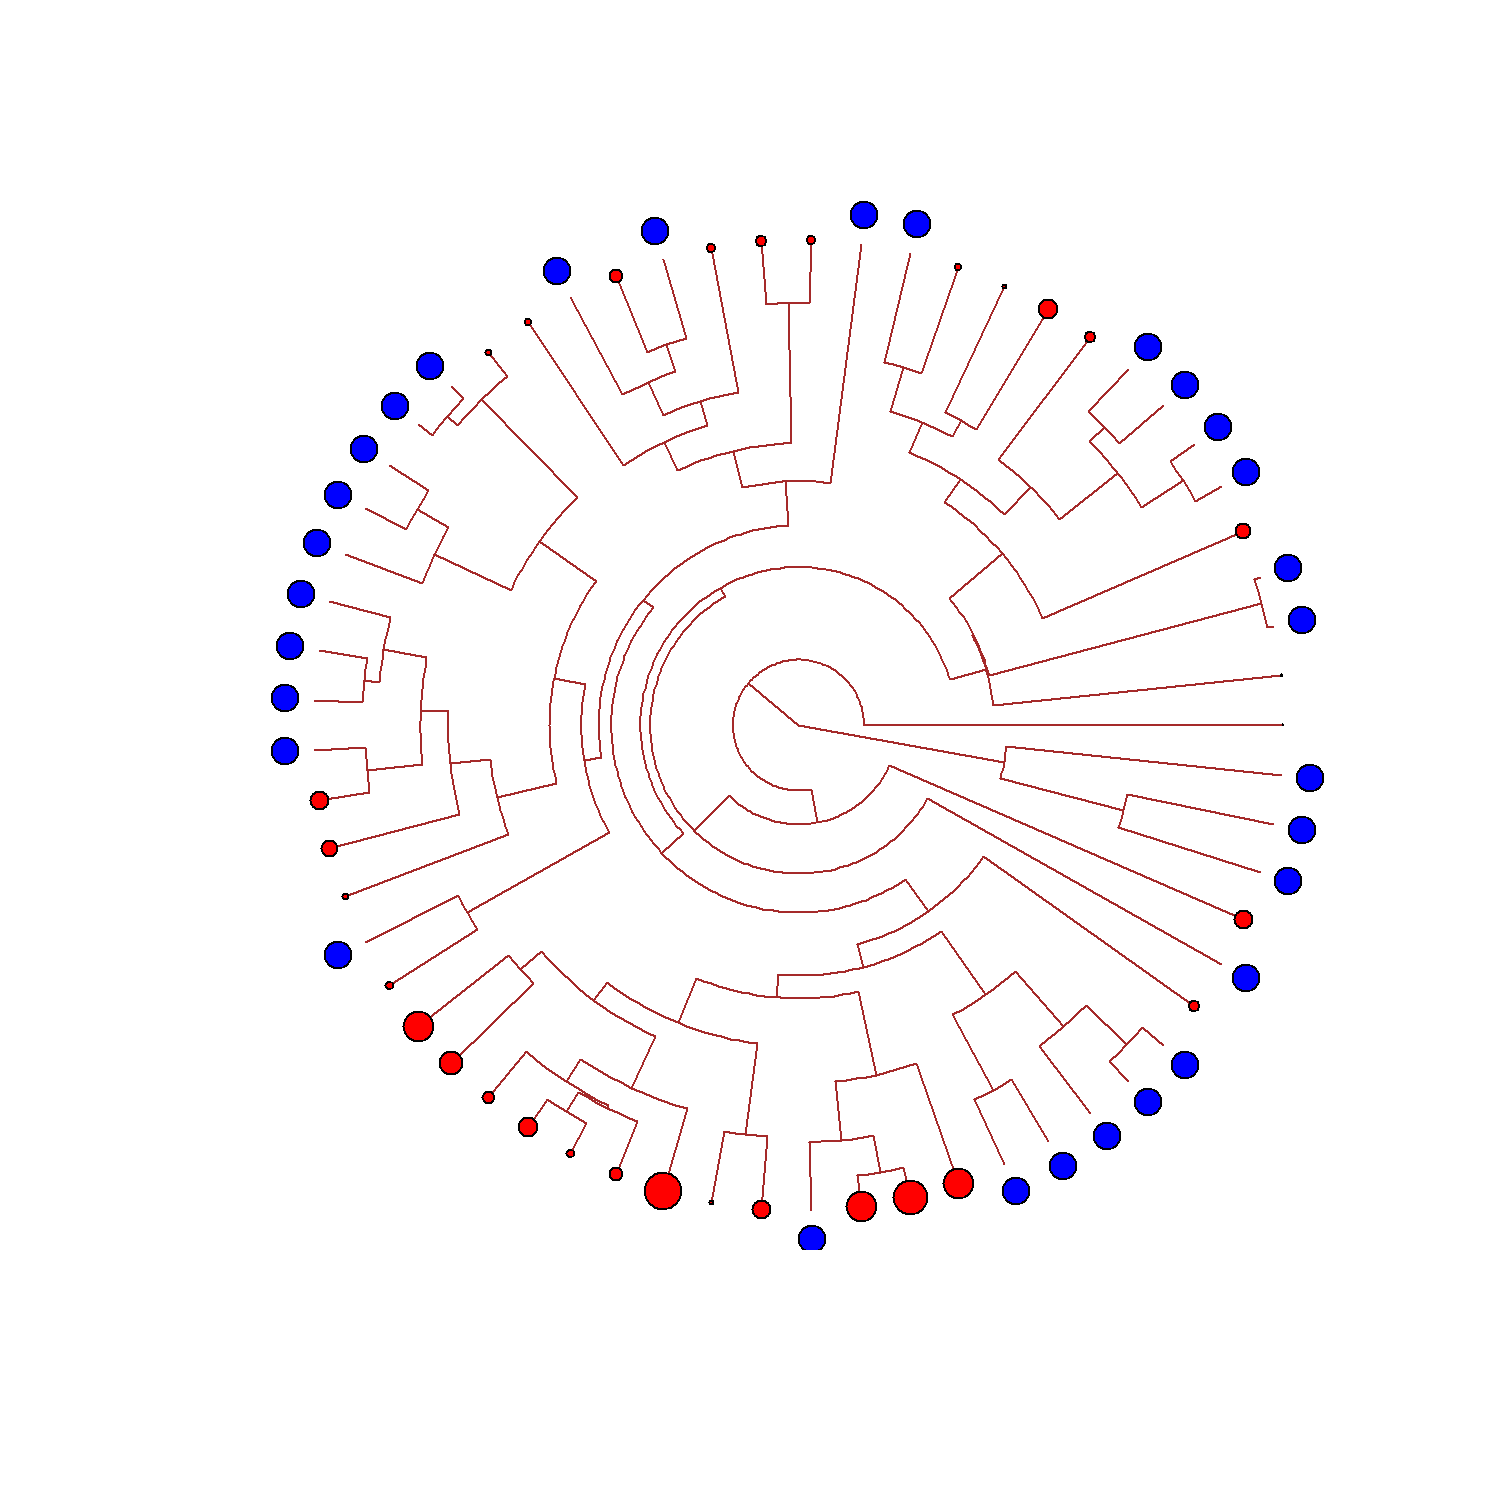

In [66]:
ape::plot.phylo(x = tree, type = "fan", show.tip.label = FALSE, show.node.label = FALSE, edge.color = "brown")
ape::tiplabels(tip = seq_along(tree$tip.label)[data$feedmode == "bite"], bg = "red", pch=21, cex = scale(data$maxtl[data$feedmode == "bite"], center = FALSE)) # the tip argument is tip number not id!!!
ape::tiplabels(tip = seq_along(tree$tip.label)[data$feedmode == "suction"], bg = "blue", pch=21, cex = 1.5, offset = 6)

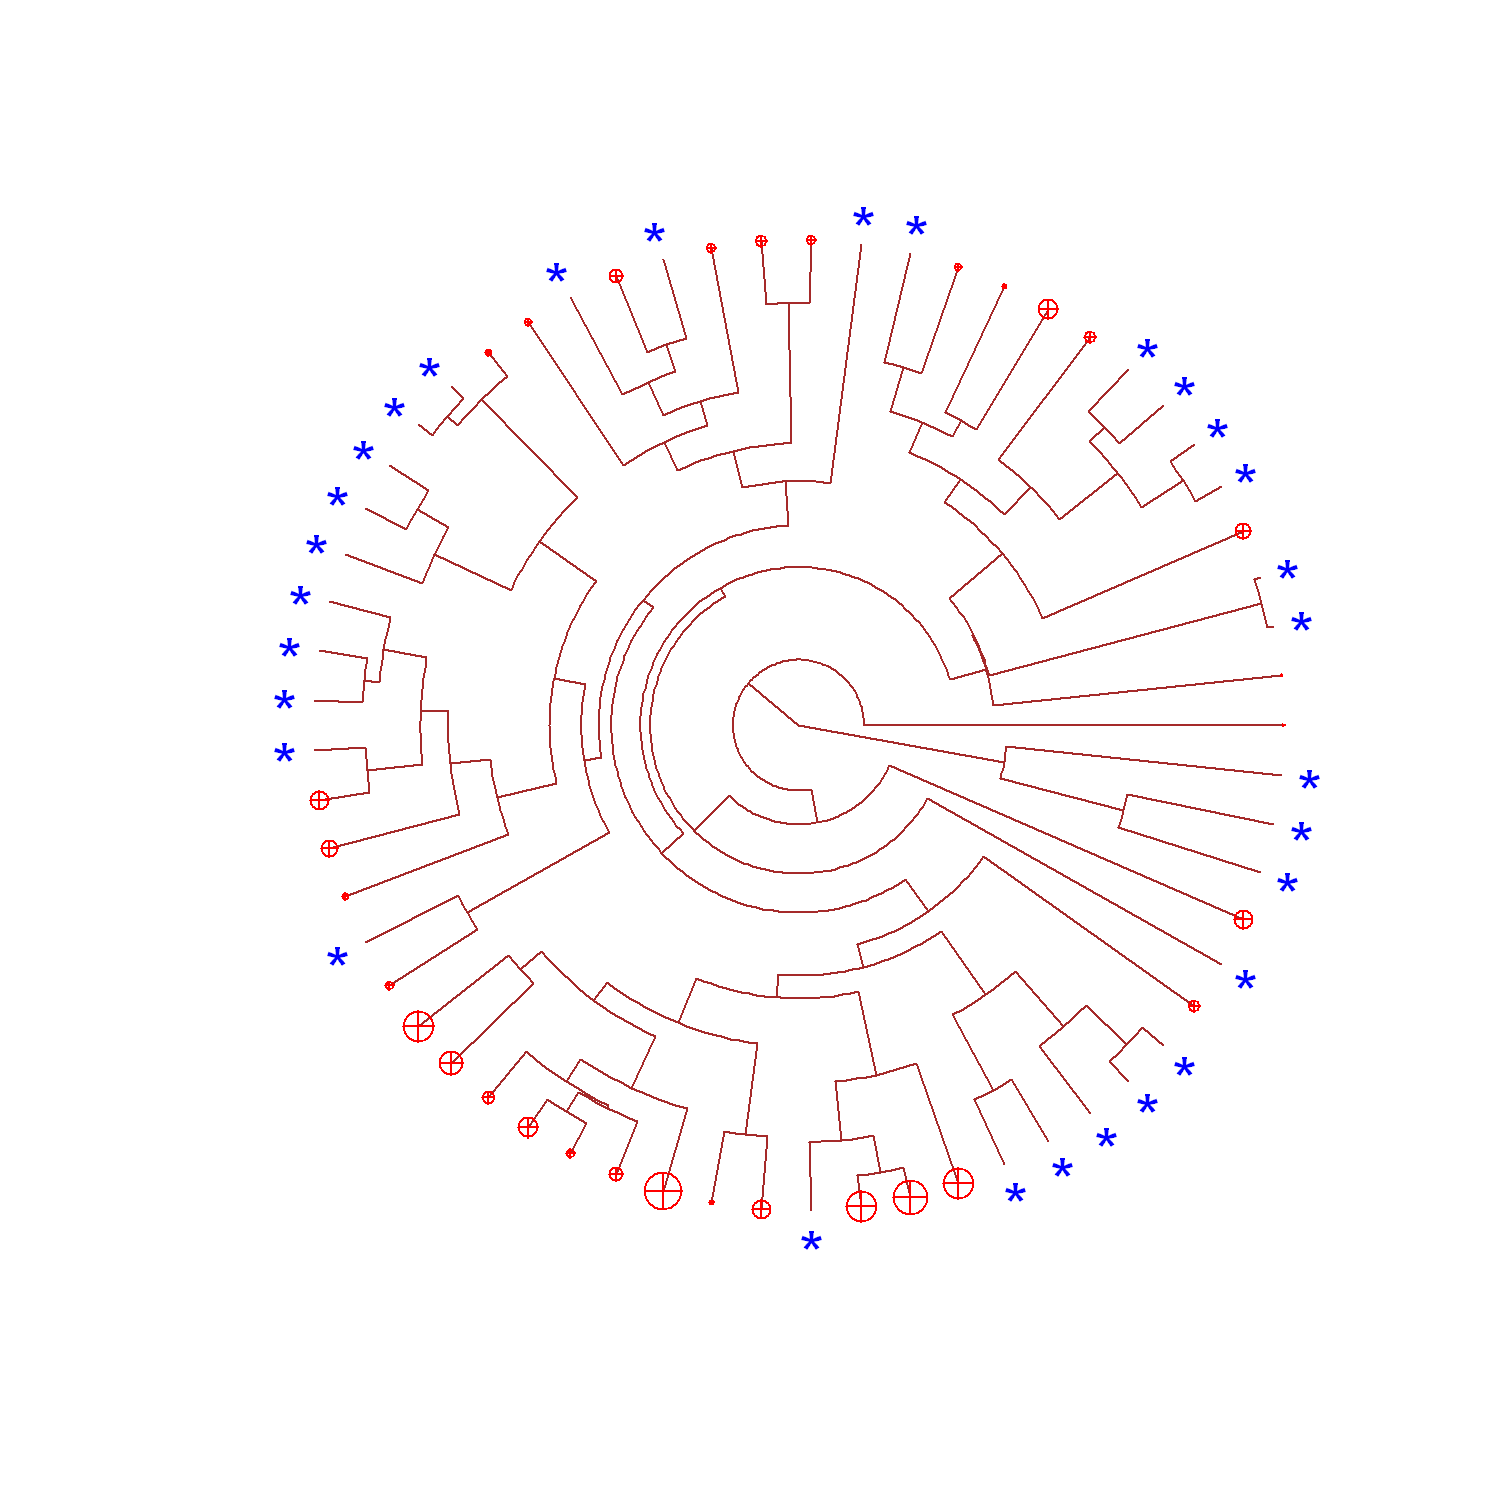

In [94]:
ape::plot.phylo(x = tree, type = "fan", show.tip.label = FALSE, show.node.label = FALSE, edge.color = "brown")
ape::tiplabels(tip = seq_along(tree$tip.label)[data$feedmode == "bite"], col = "red", pch=10, cex = scale(data$maxtl[data$feedmode == "bite"], center = FALSE)) # the tip argument is tip number not id!!!
ape::tiplabels(tip = seq_along(tree$tip.label)[data$feedmode == "suction"], col = "blue", pch='*', cex = 1.5, offset = 6)

In [68]:
head(tree$edge) # from - to

62,63
63,1
63,64
64,65
65,66
66,67


In [85]:
# we need to apply colours only to the branches at the tips
tree$edge[tree$edge[, 2] %in% (1:length(tree$tip.label)), ]

63,1
67,2
69,3
69,4
70,5
74,6
74,7
75,8
75,9
72,10
77,11
